<a href="https://colab.research.google.com/gist/plasmax/fb2ba0b61d3ca2e884e53b14f7a2513e/flowmatchingmnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Super-Simple bad example

Key references:
  [FM]   Lipman et al., "Flow Matching for Generative Modeling" (2022)
           https://arxiv.org/abs/2210.02747

$\mathcal{u}(x|x_1) = \frac{x_1 - (1 - σ_{min})x}{1 - (1 - σ_{min})t},$ [FM §3, Eq. 21]

$\psi_t(x) = (1 - (1 - \sigma_{\min})t)x + tx_1,$ [FM §3, Eq. 22]




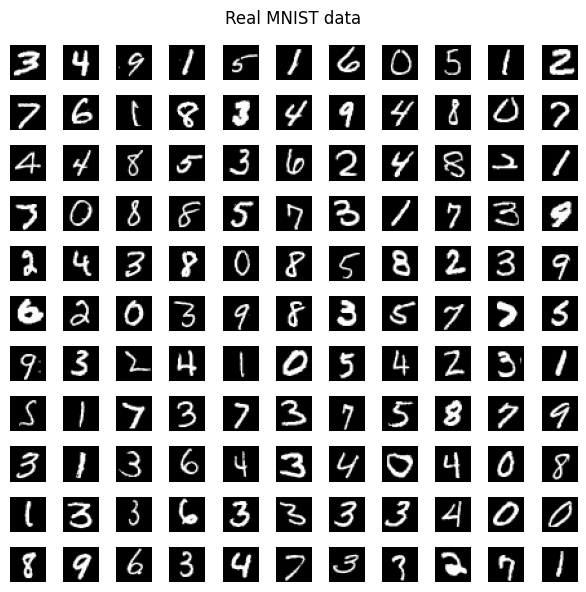

step 0000 | loss 1.9259


In [ ]:
import torch
import torch.nn as nn
from itertools import cycle
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# -------------------------
# Data
# -------------------------

device = "cuda" if torch.cuda.is_available() else "cpu"

tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2 - 1),   # [0,1] -> [-1,1]
])
BATCH_SIZE = 128
ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

def show_contactsheet(x, title, n=64):
    x = x[:n].detach().cpu()
    x = (x + 1) / 2
    x = x.clamp(0, 1)

    rows = cols = int(n ** 0.5)
    fig, axs = plt.subplots(rows, cols, figsize=(6, 6))
    for i, ax in enumerate(axs.flat):
        ax.imshow(x[i, 0], cmap="gray")
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

real_batch, _ = next(iter(dl))
show_contactsheet(real_batch, "Real MNIST data", n=BATCH_SIZE)


##
def get_1d_sines(num_pixels, dim):
    """Generates a fixed [num_pixels, dim] sinusoidal positional encoding matrix."""
    inv_freq = 1.0 / (10000 ** (torch.arange(0, dim, 2).float() / dim))
    pos = torch.arange(num_pixels).float()

    # Outer product to get grid of angles
    sin_input = torch.outer(pos, inv_freq).to(device)

    # Alternating sine and cosine
    emb = torch.zeros(num_pixels, dim, device=device)
    emb[:, 0::2] = torch.sin(sin_input)
    emb[:, 1::2] = torch.cos(sin_input)
    return emb

##
# -------------------------
# Linear-only MLP velocity field
# -------------------------

class LinearVelocityMLP(nn.Module):
    def __init__(self, dim=28*28, hidden=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1 + 10, hidden),
            nn.Linear(hidden, hidden),
            nn.Linear(hidden, hidden),
            nn.Linear(hidden, hidden),
            nn.Linear(hidden, hidden),
            nn.Linear(hidden, dim),
        )

        # self.register_buffer("pos_emb", torch.linspace(-1, 1, dim))
        # position = torch.arange(dim).float()
        # self.register_buffer("pos_emb", torch.sin(position * (2 * torch.pi / dim)))

        # self.pos_emb = nn.Parameter(torch.randn(1, dim) * 0.02)

        # Generate normalized grid coordinates (-1 to 1) for a 28x28 image
        grid_y, grid_x = torch.meshgrid(torch.linspace(-1, 1, 28), torch.linspace(-1, 1, 28), indexing="ij")

        # Create simple spatial frequency waves
        pos_emb = torch.sin(grid_x * torch.pi) + torch.cos(grid_y * torch.pi)
        self.register_buffer("pos_emb", pos_emb.flatten()) # Shape: [784]

    def forward(self, x, t, y):
        # x: [B, 784], t: [B, 1], y: [B]
        # print(f"{x.shape}, {self.pos_emb.shape}")
        x = x + self.pos_emb

        y = F.one_hot(y, num_classes=10)
        if y.shape[0] == 1:
          y = y.expand(x.shape[0], -1)
        return self.net(torch.cat([x, t, y], dim=-1))

model = LinearVelocityMLP().to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3)

# -------------------------
# Flow matching loss
# -------------------------

def compute_loss(model, x1, y):
    B = x1.shape[0]
    x1 = x1.view(B, -1)

    x0 = torch.randn_like(x1)          # noise sample
    t = torch.rand(B, 1, device=x1.device)

    xt = (1 - t) * x0 + t * x1        # point along path
    target_v = x1 - x0                # true velocity for straight path

    pred_v = model(xt, t, y)
    loss = F.mse_loss(pred_v, target_v)

    return loss

# -------------------------
# Training
# -------------------------

real, _ = next(iter(dl))

train_steps = 1000

# for step, (x1, _) in enumerate(dl):
for step, (x1, y) in zip(range(train_steps), cycle(dl)):
    x1 = x1.to(device)
    y = y.to(device)

    loss = compute_loss(model, x1, y)

    opt.zero_grad()
    loss.backward()
    opt.step()

    if step % 100 == 0:
        print(f"step {step:04d} | loss {loss.item():.4f}")

    # if step == 1000:
    #     break

# -------------------------
# Sampling by integrating the learned velocity field
# -------------------------

@torch.no_grad()
def sample(model, y, n=64, steps=50):
    model.eval()

    x = torch.randn(n, 28 * 28, device=device)
    dt = 1.0 / steps

    for i in range(steps):
        t = torch.full((n, 1), i / steps, device=device)
        v = model(x, t, y)
        x = x + dt * v

    return x.view(n, 1, 28, 28)

y = torch.Tensor([0]).to(dtype=torch.long, device=device)
samples = sample(model, y, n=16, steps=50)
print(samples.shape)
show_contactsheet(samples, "Linear-only flow matching samples", n=16)

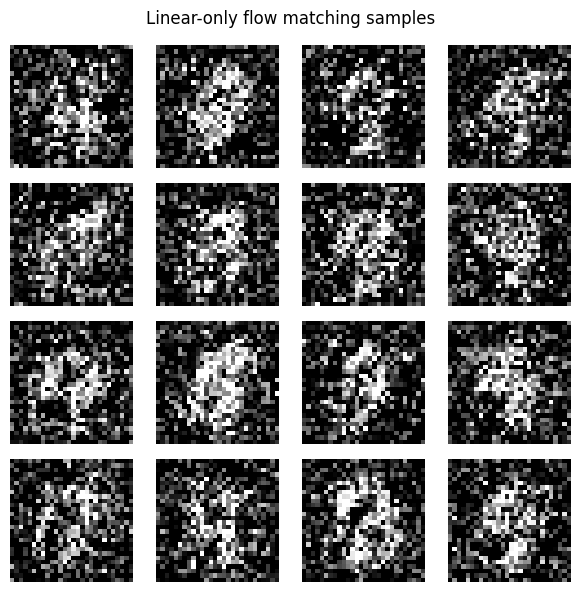

In [ ]:
y = torch.Tensor([9]).to(dtype=torch.long, device=device)
samples = sample(model, y, n=16, steps=50)
show_contactsheet(samples, "Linear-only flow matching samples", n=16)

In [ ]:
torch.Tensor([0, 1, 2, 5, 6, 73, 4, 7]).view(2, 2, 2).contiguous()

tensor([[[ 0.,  1.],
         [ 2.,  5.]],

        [[ 6., 73.],
         [ 4.,  7.]]])

In [ ]:
# torch.linspace(-1, 1, 6)

torch.sin(torch.arange(6) * (2 * torch.pi / 6))

tensor([ 0.0000e+00,  8.6603e-01,  8.6603e-01, -8.7423e-08, -8.6603e-01,
        -8.6603e-01])

64
torch.Size([64, 1, 28, 28])
torch.Size([64, 784])
(28, 28)


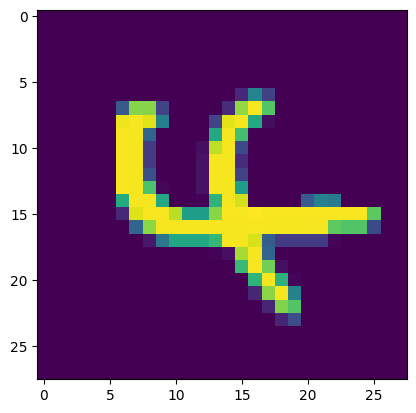

In [ ]:
real_batch, _ = next(iter(dl))
B = real_batch.shape[0]
print(B)
print(real_batch.shape)
print(real_batch.view(B, -1).shape)
print(real_batch[0][0].detach().cpu().float().numpy().shape)
plt.imshow(real_batch[0][0].detach().cpu().float().numpy())

## Much better example

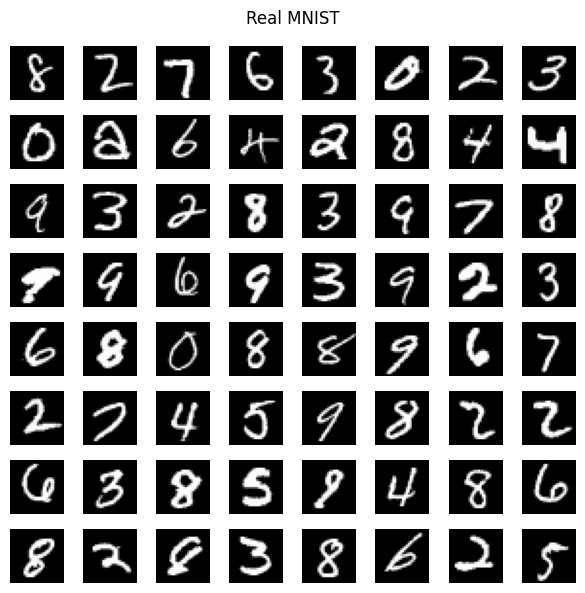

0 1.8297309875488281


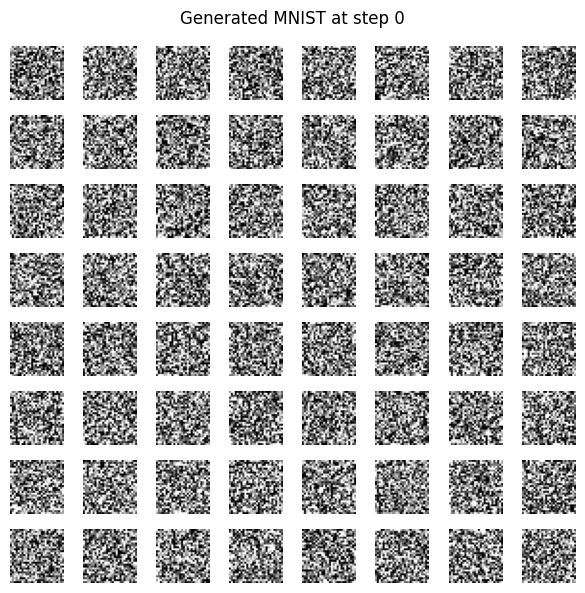

500 0.28214144706726074


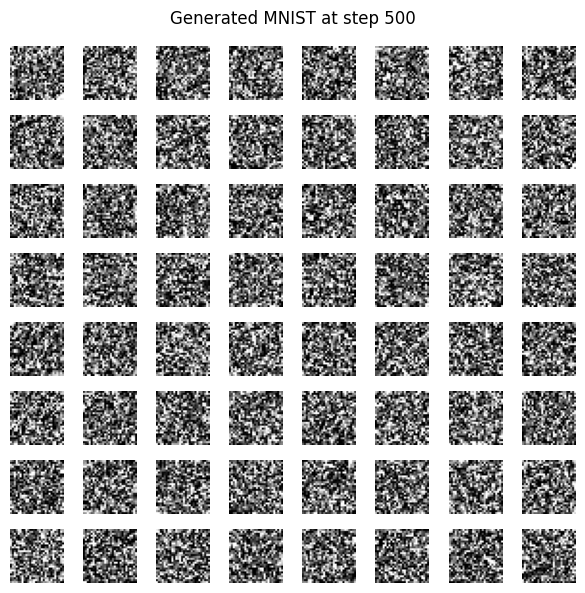

1000 0.2548472583293915


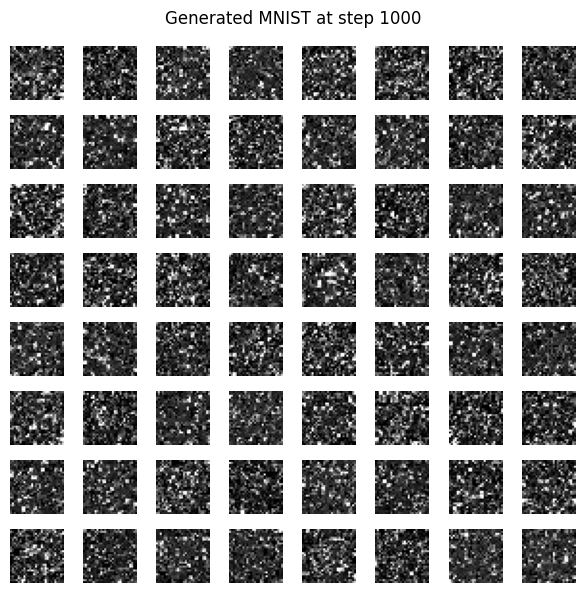

1500 0.22537754476070404


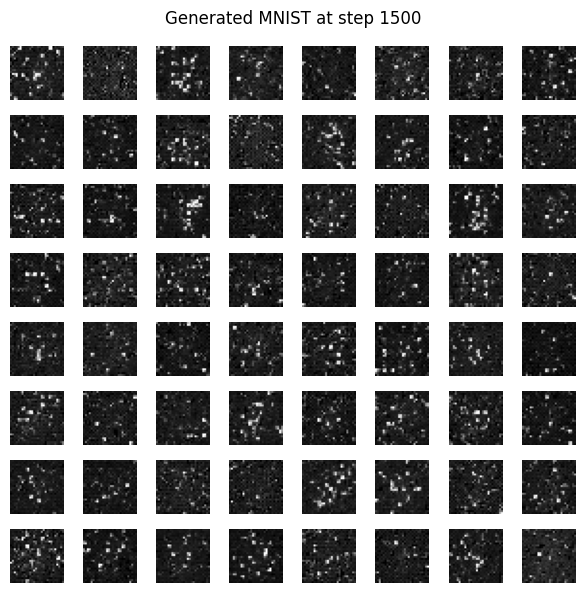

2000 0.16833698749542236


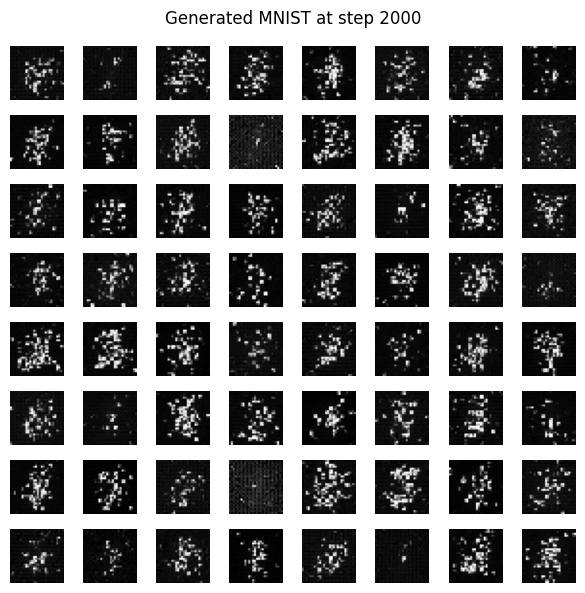

2500 0.14708392322063446


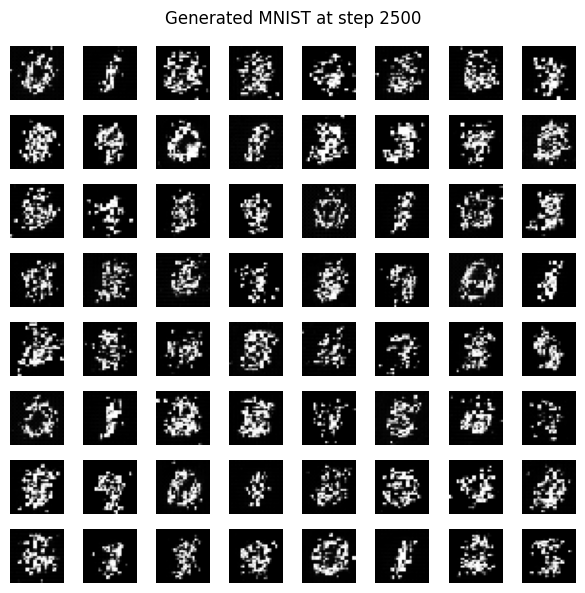

3000 0.13540266454219818


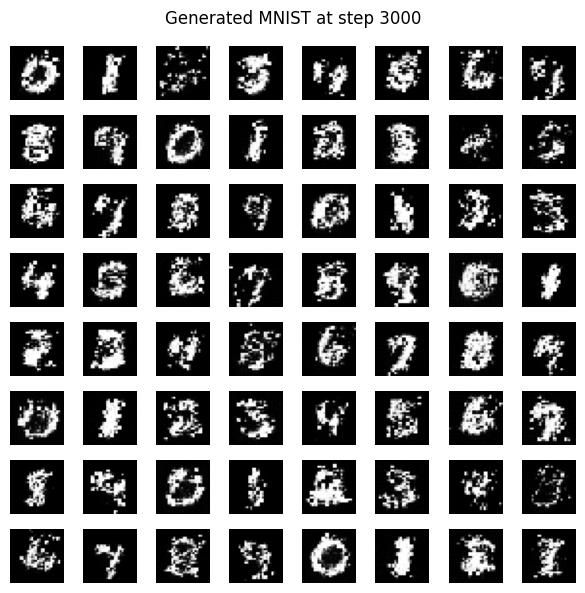

3500 0.12856794893741608


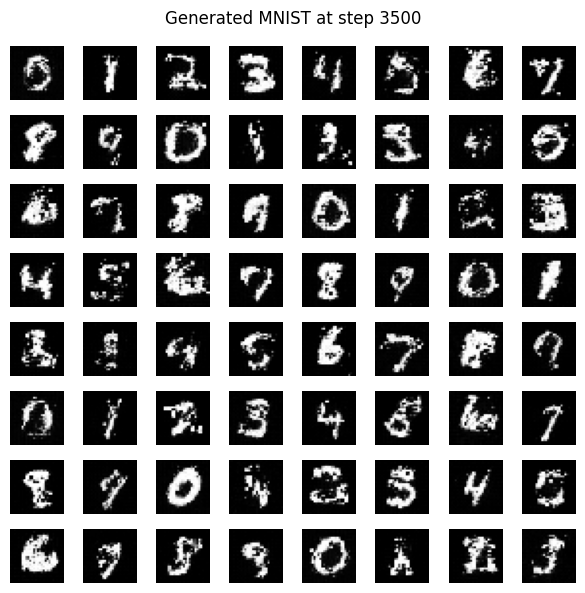

4000 0.1284661740064621


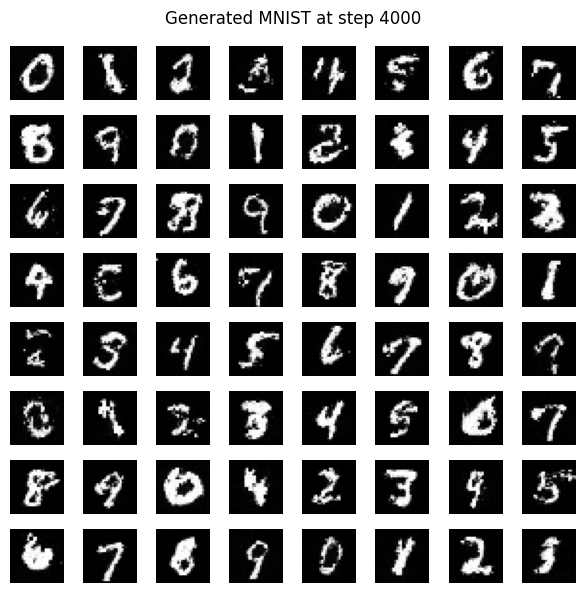

4500 0.12208689004182816


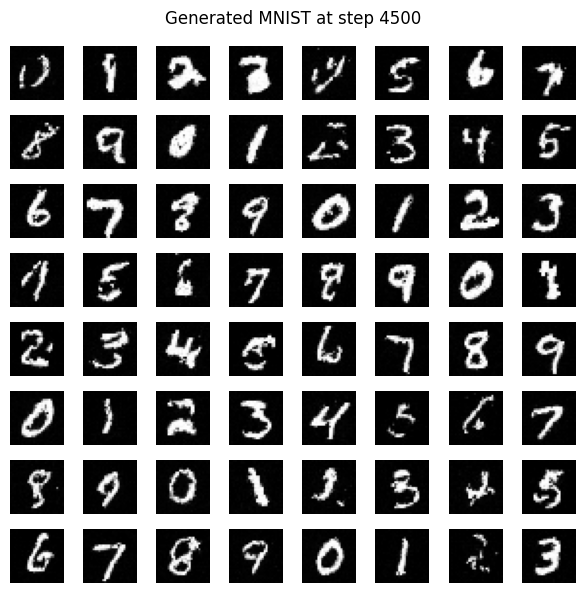

5000 0.12429939955472946


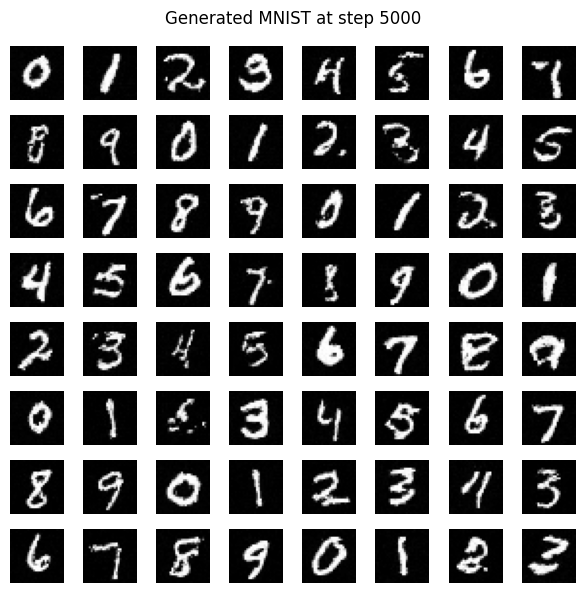

5500 0.12067016214132309


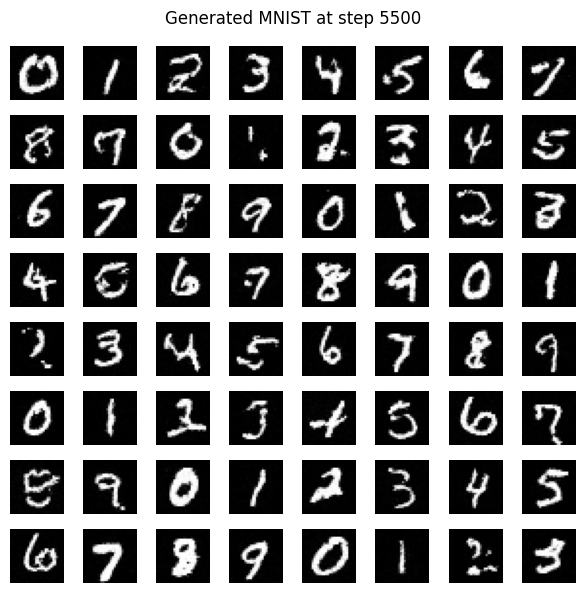

6000 0.11567208915948868


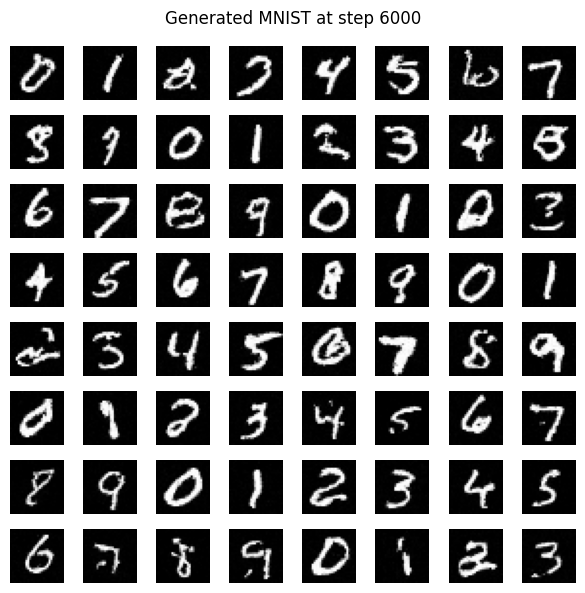

6500 0.1141102984547615


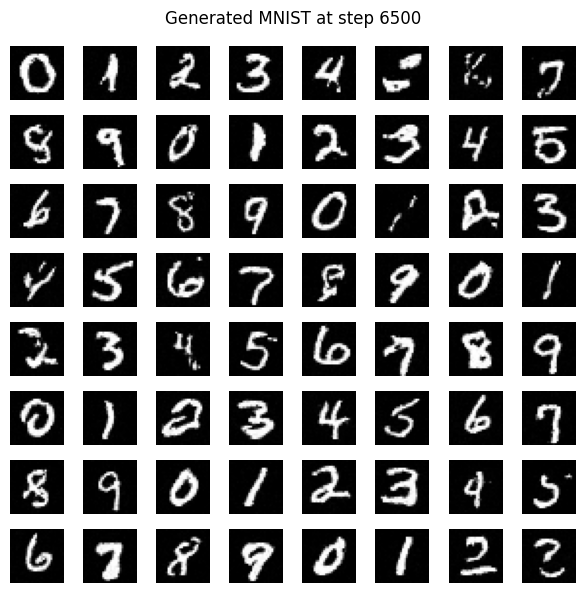

7000 0.11229445040225983


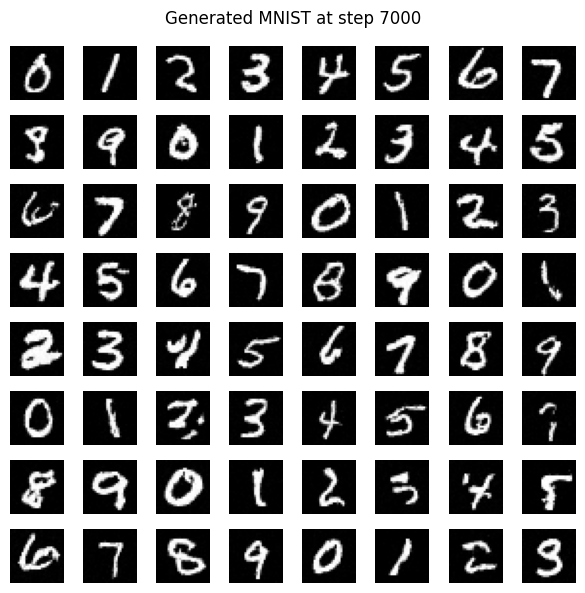

7500 0.12250205129384995


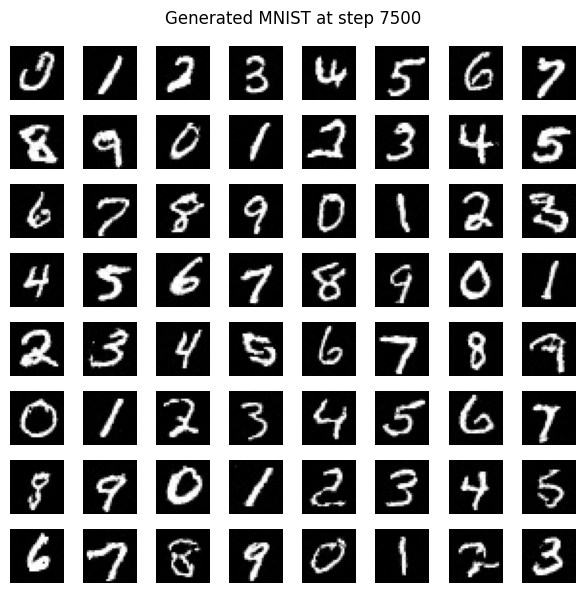

8000 0.11511778831481934


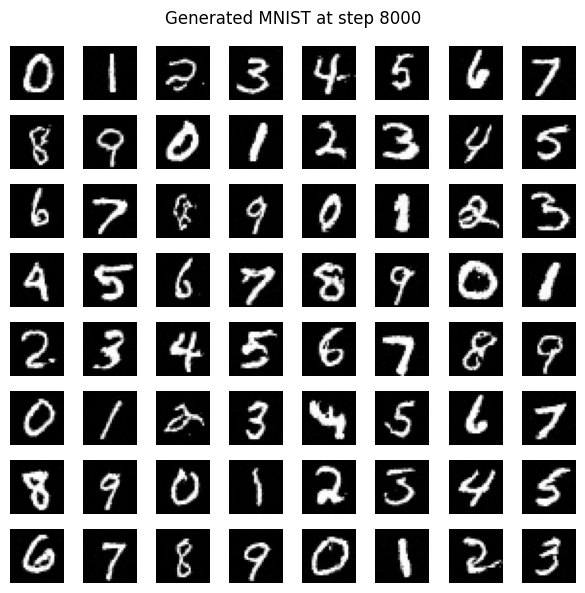

8500 0.11031800508499146


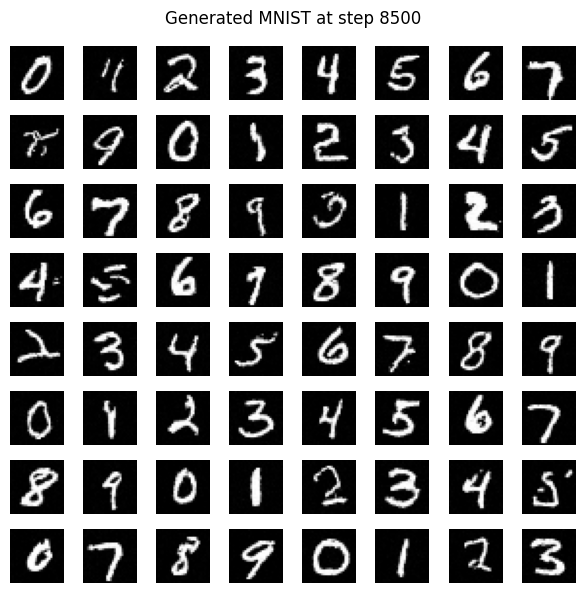

9000 0.11336442828178406


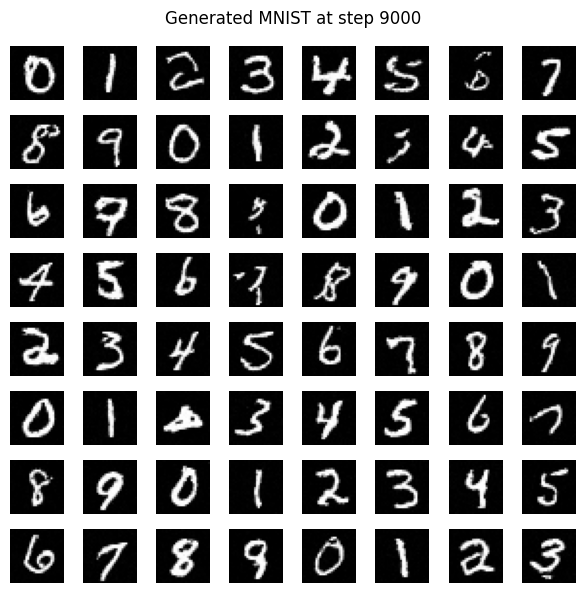

9500 0.11078781634569168


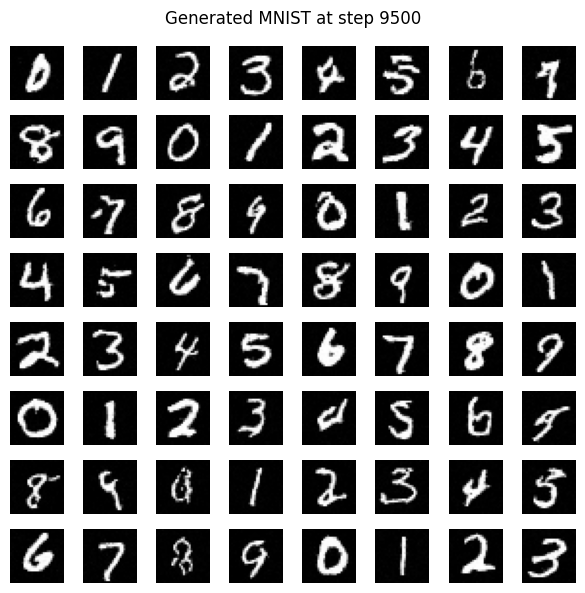

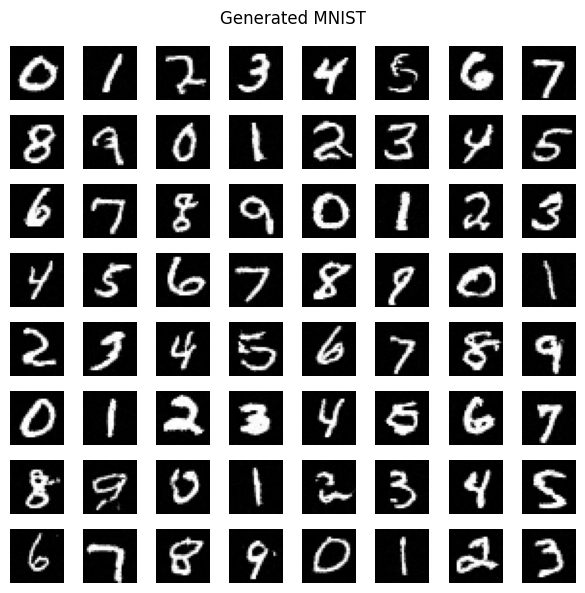

In [ ]:
import copy, math, torch
from itertools import cycle
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

tfm = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x * 2 - 1)])
ds = datasets.MNIST("./data", train=True, download=True, transform=tfm)
dl = DataLoader(ds, batch_size=256, shuffle=True, drop_last=True)


def timestep_embedding(t, dim):                            # Fourier time [B,D] [DiT]
    half = dim // 2
    f = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
    e = t * f[None]
    return torch.cat([e.sin(), e.cos()], dim=-1)

def modulate(x, shift, scale):                             # adaLN mod [B,N,D] [DiT]
    return x * (1 + scale[:, None]) + shift[:, None]

class Block(nn.Module):
    def __init__(self, d, heads):
        super().__init__()
        self.n1, self.n2 = nn.LayerNorm(d, elementwise_affine=False), nn.LayerNorm(d, elementwise_affine=False)
        self.attn = nn.MultiheadAttention(d, heads, batch_first=True)
        self.mlp = nn.Sequential(nn.Linear(d, 4*d), nn.GELU(), nn.Linear(4*d, d))
        self.mod = nn.Sequential(nn.SiLU(), nn.Linear(d, 6*d))
        nn.init.zeros_(self.mod[-1].weight); nn.init.zeros_(self.mod[-1].bias)  # zero init [DiT]

    def forward(self, x, c):                               # tokens [B,N,D], cond [B,D]
        s1, q1, g1, s2, q2, g2 = self.mod(c).chunk(6, 1)
        h = modulate(self.n1(x), s1, q1)
        x = x + g1[:, None] * self.attn(h, h, h, need_weights=False)[0]
        x = x + g2[:, None] * self.mlp(modulate(self.n2(x), s2, q2))
        return x                                           # tokens [B,N,D]

class FinalBlock(nn.Module):
    def __init__(self, d, patch):
        super().__init__()
        self.norm = nn.LayerNorm(d, elementwise_affine=False)
        self.adaLN_proj = nn.Sequential(nn.SiLU(), nn.Linear(d, 2 * d))
        self.linear = nn.Linear(d, patch * patch)
        nn.init.zeros_(self.adaLN_proj[-1].weight); nn.init.zeros_(self.adaLN_proj[-1].bias)
        nn.init.zeros_(self.linear.weight); nn.init.zeros_(self.linear.bias)

    def forward(self, x, c):
        shift, scale = self.adaLN_proj(c).chunk(2, dim=1)
        return self.linear(modulate(self.norm(x), shift, scale))

class TinyDiTFlow(nn.Module):
    def __init__(self, d=128, depth=4, heads=4, patch=2, classes=11):
        super().__init__()
        self.patch, self.side = patch, 28 // patch
        self.patchify = nn.Conv2d(1, d, patch, patch)       # patch tokens [DiT]
        self.pos = nn.Parameter(torch.randn(1, self.side**2, d) * 0.02)
        self.time = nn.Sequential(nn.Linear(d, d), nn.SiLU(), nn.Linear(d, d))
        self.label = nn.Embedding(classes, d)               # class cond [CFG]
        self.blocks = nn.ModuleList([Block(d, heads) for _ in range(depth)])

        # TODO: replace this:
        # self.final = nn.Sequential(nn.LayerNorm(d), nn.Linear(d, patch * patch))
        # nn.init.zeros_(self.final[-1].weight); nn.init.zeros_(self.final[-1].bias)

        # ... with this:
        self.final = FinalBlock(d, patch)

    def unpatchify(self, x):                                # pixels [B,1,28,28]
        B, N, P2 = x.shape
        p, s = self.patch, self.side
        x = x.view(B, s, s, p, p).permute(0, 1, 3, 2, 4)
        return x.reshape(B, 1, 28, 28)

    def forward(self, x, t, y):                             # image [B,1,28,28]
        h = self.patchify(x).flatten(2).transpose(1, 2) + self.pos
        c = self.time(timestep_embedding(t * 1000, h.shape[-1])) + self.label(y)
        for block in self.blocks:
            h = block(h, c)
        return self.unpatchify(self.final(h, c))            # velocity [B,1,28,28]

model = TinyDiTFlow().to(device)
ema = copy.deepcopy(model).eval()
opt = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=0.01)

def ot_pair(x0, x1, y):                                     # batch OT [OT-CFM]
    cost = torch.cdist(x0.flatten(1), x1.flatten(1)).detach().cpu()
    _, j = linear_sum_assignment(cost)
    j = torch.tensor(j, device=x1.device)
    return x1[j], y[j]

def compute_loss(model, x1, y):
    B = x1.shape[0]
    x0 = torch.randn_like(x1)                               # base noise [FM]
    x1, y = ot_pair(x0, x1, y)                              # straighter paths [OT-CFM]
    t = torch.sigmoid(torch.randn(B, 1, device=device))      # useful times [SD3]
    xt = (1 - t[:, :, None, None]) * x0 + t[:, :, None, None] * x1
    v = x1 - x0                                             # target flow [FM]
    y = torch.where(torch.rand(B, device=device) < 0.1, 10, y)  # label dropout [CFG]
    return F.mse_loss(model(xt, t, y), v)

@torch.no_grad()
def update_ema():
    for a, b in zip(ema.parameters(), model.parameters()):
        a.lerp_(b, 0.001)                                   # smoother weights [EDM]

def show(x, title, n=64):
    x = ((x[:n].detach().cpu() + 1) / 2).clamp(0, 1)       # images [N,1,28,28]
    r = c = int(n**0.5)
    fig, ax = plt.subplots(r, c, figsize=(6, 6))
    for i, a in enumerate(ax.flat):
        a.imshow(x[i, 0], cmap="gray")
        a.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


@torch.no_grad()
def sample(model, n=64, steps=50, guidance=2.0):
    model.eval()
    x = torch.randn(n, 1, 28, 28, device=device)             # noise [N,1,28,28]
    y = torch.arange(n, device=device) % 10                  # labels [N]
    null = torch.full_like(y, 10)

    def cfg_v(x, t):
        # vc = model(x, t, y)
        # vu = model(x, t, null)

        # we can batch then split cond and uncond to sample faster
        vc, vu = model(
            torch.cat([x,x]),
            torch.cat([t,t]),
            torch.cat([y,null])).chunk(2, dim=0)

        return vu + guidance * (vc - vu)                    # guided velocity [CFG]

    for i in range(steps):
        t0 = torch.full((n, 1), i / steps, device=device)
        t1 = torch.full((n, 1), (i + 1) / steps, device=device)
        dt = 1 / steps
        v0 = cfg_v(x, t0)
        xe = x + dt * v0
        v1 = cfg_v(xe, t1)
        x = x + 0.5 * dt * (v0 + v1)                         # Heun step [EDM]
    return x.clamp(-1, 1)


real, _ = next(iter(dl))
show(real, "Real MNIST")

train_steps = 10000

for step, (x1, y) in zip(range(train_steps), cycle(dl)):
    x1, y = x1.to(device), y.to(device)

    loss = compute_loss(model, x1, y)

    opt.zero_grad()
    loss.backward()
    opt.step()
    update_ema()

    if step % 500 == 0:
        print(step, loss.item())
        show(sample(ema), f"Generated MNIST at step {step}")


show(sample(ema), "Generated MNIST")
